# Fine tune AG-NEWS Classification Model to IMDB Dataset With LORA

In [132]:
import torch
import math
import time
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from torch.nn import CrossEntropyLoss


#### **Dataset Loading**

In [133]:
dataset = load_dataset("AG_NEWS")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [134]:
dataset['train'][0]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2}

In [135]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
tokenizer

BertTokenizer(name_or_path='bert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [136]:
label_list = []

for idx,data in enumerate(dataset['train']):
    label_list.append(dataset['train'][idx]['label'])

num_classes = len(set(label_list))
num_classes

4

In [137]:
ag_news_labels = {0: "world", 1:"sports", 2:"business", 3:"sci/tech"}

#### **Define Tokenizer Function**

In [138]:
def tokenize_text (data):
    return tokenizer(data['text'], padding='max_length', truncation=True, max_length=128)


In [139]:
dataset = dataset.map(tokenize_text, batched=True)


In [140]:
dataset.column_names

{'train': ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
 'test': ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']}

In [141]:
dataset = dataset.rename_column('label', 'labels')


In [142]:
dataset.set_format(type='torch', columns=['labels', 'input_ids', 'attention_mask'])

In [143]:
dataset_train = dataset['train']
dataset_test = dataset['test']

In [144]:
dataset_train[0]

{'labels': tensor(2),
 'input_ids': tensor([  101,  6250,  1457,   119, 10169,   140,  9598,  4388, 14000,  1103,
          2117,   113, 11336, 27603,   114, 11336, 27603,   118,  6373,   118,
         18275,  1116,   117,  6250,  1715,   112,   188,   173, 11129,  1979,
           165,  1467,  1104, 18737,   118,   172,  5730,  4724,   117,  1132,
          3195,  2448,  1254,   119,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,  

In [145]:
dataset_train[0].keys()

dict_keys(['labels', 'input_ids', 'attention_mask'])

In [146]:
dataset_train[0]

{'labels': tensor(2),
 'input_ids': tensor([  101,  6250,  1457,   119, 10169,   140,  9598,  4388, 14000,  1103,
          2117,   113, 11336, 27603,   114, 11336, 27603,   118,  6373,   118,
         18275,  1116,   117,  6250,  1715,   112,   188,   173, 11129,  1979,
           165,  1467,  1104, 18737,   118,   172,  5730,  4724,   117,  1132,
          3195,  2448,  1254,   119,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,  

In [147]:
dataset_test[0]

{'labels': tensor(2),
 'input_ids': tensor([  101, 11284,  1116,  1111,   157,   151, 12966,  1170,  7430,  1913,
          1116,  4311,  3239,  1120,  6217,  1203,  5727,  1474,  1152,  1132,
           112,  9333,   112,  1170,  7430,  1114, 18178,  6486,  3016,  3467,
         12556, 13830,  1233,   119,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,  

**Split train set**

In [148]:
train_valid_split = dataset_train.train_test_split(test_size=0.1, seed=42)

### **Define Dataloaders**

In [149]:
BATCH_SIZE = 8

In [150]:
train_dataloader = DataLoader(train_valid_split['train'], batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(train_valid_split['test'], batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

### **Define Text-Embedding**

In [151]:
class TextEmbeddings(nn.Module):
    
    def __init__(self, vocab_size, embed_dims, dropout):
        super().__init__()
        
        self.embed_dim = embed_dims
        self.dropout = nn.Dropout(dropout)
        self.embeddings = nn.Embedding(vocab_size, embed_dims)
    
    
    def forward (self, input_tokens):
        # input_token -> [batch_size, seq_len]
        embed_out = self.embeddings(input_tokens) * math.sqrt(self.embed_dim)
        return self.dropout(embed_out)

### **Positional Embeddings**

In [152]:
class PositionalEmbedding (nn.Module):
    
    def __init__(self, vocab_size, d_model, max_seq_len, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        
        positions = torch.arange(0, max_seq_len).unsqueeze(1)
        
        pe = torch.zeros(max_seq_len, d_model).float()
        
        div_term = torch.exp(
            torch.arange(0,d_model,2) * (-math.log(10000)/d_model)
        )
        
        pe[:,0::2] = torch.sin(positions * div_term)
        pe[:,1::2] = torch.cos(positions * div_term)
        
        pe = pe.unsqueeze(0)
        
        self.register_buffer("pe",pe)
        
    def forward(self, text_embeddings):
        
        text_embed_size = text_embeddings.size(1)
        pos_embed = text_embeddings + self.pe[:,0:text_embed_size,:]
        return self.dropout(pos_embed)
        

### **Define Model**

In [153]:
print(torch.cuda.is_available())

True


In [154]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [155]:
class CustomClassificationModel(nn.Module):
    
    def __init__(self, vocab_size, d_model,n_classes ,n_layers, n_heads, dropout, dim_feedforward):
        super().__init__()
        
        self.embeddings = TextEmbeddings(vocab_size,d_model, dropout)
        self.pos_embeddings = PositionalEmbedding(vocab_size,d_model,2000, dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model, dim_feedforward=dim_feedforward, 
                                                   batch_first=True, nhead=n_heads)
        
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer=encoder_layer, 
                                                         num_layers=n_layers)
        
        self.linear_layer = nn.Linear(d_model,n_classes)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_ids, attention_mask:None):
        # input_ids -> [batch_size, seq_len]
        
        embed_out = self.embeddings(input_ids) 
        pos_out = self.pos_embeddings(embed_out)
        
        src_key_padding_mask = (attention_mask == 0) if attention_mask is not None else None
        
        transformer_out = self.transformer_encoder(pos_out,src_key_padding_mask = src_key_padding_mask)
        
        out = transformer_out.mean(dim=1)
        
        out = self.linear_layer(out)
        
        return out
        

### **Define Model Instance** 

In [156]:
vocab_size = tokenizer.vocab_size
d_model = 128 
num_layers = 2
num_heads = 2
dropout = 0.1
dim_feedforward = 256  

In [157]:
custom_model = CustomClassificationModel(vocab_size, d_model, num_classes, num_layers,
                                        num_heads, dropout, dim_feedforward)

In [158]:
custom_model.to(device)

CustomClassificationModel(
  (embeddings): TextEmbeddings(
    (dropout): Dropout(p=0.1, inplace=False)
    (embeddings): Embedding(28996, 128)
  )
  (pos_embeddings): PositionalEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (linear_layer): Linear(in_features=128, out

### **Define Model Prediction**

In [159]:
def model_predict (model:CustomClassificationModel, input:str):
    
    with torch.no_grad():
        tokens = tokenizer(input, return_tensors='pt').to(device)
        input_ids = tokens['input_ids']
        attention_mask = tokens['attention_mask']
    
        output = model(input_ids,attention_mask)
        out = torch.argmax(output, dim=-1)
        
        predict_label = ag_news_labels[out.item()]
        
        return predict_label
    

In [160]:
sample = "The United Nations held an emergency meeting after rising tensions between neighboring countries sparked concerns about regional stability."

In [161]:
sample_predict_label = model_predict(custom_model,sample)
sample_predict_label

'sci/tech'

### **Define Model Evaluation**

In [162]:
def model_eval (model:CustomClassificationModel, dataloader:DataLoader):
    
    model.eval()
    total_accuracy = 0
    total_count = 0
    
    with torch.no_grad():
        
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']
            
            output = model(input_ids,attention_mask)
            
            predict_out = torch.argmax(output,dim=-1)
            
            total_accuracy += (predict_out == labels).sum().item()
            total_count += labels.size(0)

    return total_accuracy/total_count
        

In [163]:
pre_train_model_accuracy = model_eval(custom_model,test_dataloader)

In [164]:
print(f"accuracy of custom model before training: {pre_train_model_accuracy * 100:.2f}%")

accuracy of custom model before training: 26.32%


### **Define Model Training**

##### Model Training Parameters

In [165]:
LR = 1e-4  
criterion = CrossEntropyLoss()
optimizer = AdamW(custom_model.parameters(),lr=LR)

In [166]:
num_epochs = 5
total_steps = num_epochs * len(train_dataloader)
warm_steps = int(total_steps * 0.1)

scheduler = get_linear_schedule_with_warmup(optimizer,warm_steps,total_steps)

In [167]:
def model_train(model:CustomClassificationModel, dataloader:DataLoader, criterion:CrossEntropyLoss,
                optimizer:AdamW, lr_scheduler,n_epochs):
    
    total_accuracy = []
    total_loss = []
    accuracy_old = 0
    
    start_time = time.time()
    
    for epoch in tqdm(range(1, n_epochs+1),  desc="Epochs"):
        
        model.train()
        epoch_loss = 0
        
        for i, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch}/{n_epochs}")):
            
            batch = {k: v.to(device) for k, v in batch.items()}
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']
            
            optimizer.zero_grad()
            
            output = model(input_ids,attention_mask)
            loss = criterion(output, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1)
            
            optimizer.step()
            lr_scheduler.step()
            
            epoch_loss += loss.item()
            
            if i % 1000 == 0:  # ← print every 50 batches
                print(f"  batch {i}, loss: {loss.item():.4f}")
        
        epoch_loss = epoch_loss / len(dataloader)
        total_loss.append(epoch_loss)
        
        accuracy = model_eval(model, valid_dataloader)
        total_accuracy.append(accuracy)
        print(f"Epoch {epoch}/{n_epochs} - Loss: {epoch_loss} Accuracy: {accuracy}") 

        if accuracy > accuracy_old:
            accuracy_old = accuracy
            torch.save(model.state_dict(), "classification_AgNews.pt")
            print("save model epoch",epoch)
    
    end_time = time.time()
    
    print("training time: ", end_time-start_time)
    return total_accuracy, total_loss
    

In [168]:
model_accuracy, model_loss = model_train(custom_model, train_dataloader, criterion,
                                        optimizer, scheduler, num_epochs)

Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

  batch 0, loss: 1.4068


  batch 1000, loss: 1.4009


  batch 2000, loss: 1.2984


Epoch 1/5:  15%|█▍        | 2017/13500 [00:25<02:26, 78.16it/s]

...

  batch 11000, loss: 0.2895


  batch 12000, loss: 0.3872


  batch 13000, loss: 0.1237


Epochs: 100%|██████████| 5/5 [18:56<00:00, 227.25s/it]

Epoch 5/5 - Loss: 0.4285697247438754 Accuracy: 0.8393333333333334
save model epoch 5
training time:  1136.2478520870209


### **Plot the Model Output**

C:\Users\Vish\AppData\Local\Temp\ipykernel_4988\679319481.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


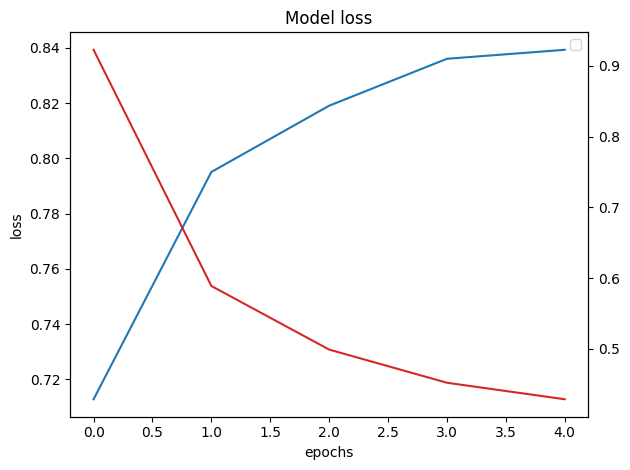

In [169]:
fig,ax1 = plt.subplots()

color = "tab:blue"
ax1.plot(model_accuracy, color = color)
ax1.set_xlabel("epochs")
ax1.set_ylabel("accuracy")
ax1.set_title("Model Accuracy")

color = "tab:red"
ax2 = ax1.twinx()
ax2.plot(model_loss, color = color)
ax1.set_ylabel("loss")
ax1.set_title("Model loss")

plt.tight_layout()
plt.legend()
plt.show()



In [170]:
sample_text = "Several world leaders signed a climate agreement during the international summit in Geneva."
sample_predict = model_predict(custom_model,sample_text)
sample_predict

'world'

### **Model Fine-Tune With LORA**

##### Load the classify model

In [171]:
classify_model =  CustomClassificationModel(vocab_size, d_model, num_classes, num_layers,
                                        num_heads, dropout, dim_feedforward)

classify_model.to(device)

CustomClassificationModel(
  (embeddings): TextEmbeddings(
    (dropout): Dropout(p=0.1, inplace=False)
    (embeddings): Embedding(28996, 128)
  )
  (pos_embeddings): PositionalEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (linear_layer): Linear(in_features=128, out

In [172]:
classify_model.load_state_dict(torch.load("classification_AgNews.pt"))
classify_model.to(device)

CustomClassificationModel(
  (embeddings): TextEmbeddings(
    (dropout): Dropout(p=0.1, inplace=False)
    (embeddings): Embedding(28996, 128)
  )
  (pos_embeddings): PositionalEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (linear_layer): Linear(in_features=128, out

### **Define LORA Layer** 

In [173]:
class LORALinear (nn.Module):
    
    def __init__(self, linear:nn.Linear, rank, alpha):
        super().__init__()
        
        self.scale = alpha / rank
        self.linear = linear
        
        self.A = nn.Parameter(torch.empty(self.linear.in_features, rank))
        self.B = nn.Parameter(torch.zeros(rank, self.linear.out_features))
        nn.init.kaiming_uniform_(self.A, a= math.sqrt(5))
    
    @property
    def weight(self):
        return self.linear.weight
    
    @property
    def bias(self):
        return self.linear.bias
        
    def forward(self, x):
        return self.linear(x) + (self.scale * (x @ self.A @ self.B))

### **Define Apply Lora Layer Function**

In [174]:
def apply_lora_layer (model:CustomClassificationModel, r: int = 4 , alpha:int = 2, 
                    classify_class:int = 2):
    
    # freeze all parameters of the model
    for param in model.parameters():
        param.requires_grad_(False)
    
    
    
    # replace all the linear layers in transformer encoder layers
    for layer in model.transformer_encoder.layers:
        
        #attention output projection layer
        layer.self_attn.out_proj = LORALinear(layer.self_attn.out_proj,r,alpha)
        #feed forward layers
        layer.linear1 = LORALinear(layer.linear1, r, alpha)
        layer.linear2 = LORALinear(layer.linear2, r, alpha)
    # replace linear_layer (output layer) with 2 classification classes
    model.linear_layer = nn.Linear(model.linear_layer.in_features, classify_class)
    
    return model    

In [175]:
Lora_model = apply_lora_layer(classify_model, r=4, alpha=4)
Lora_model.to(device)

CustomClassificationModel(
  (embeddings): TextEmbeddings(
    (dropout): Dropout(p=0.1, inplace=False)
    (embeddings): Embedding(28996, 128)
  )
  (pos_embeddings): PositionalEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): LORALinear(
            (linear): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
        )
        (linear1): LORALinear(
          (linear): Linear(in_features=128, out_features=256, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): LORALinear(
          (linear): Linear(in_features=256, out_features=128, bias=True)
        )
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1

In [176]:
# verify the model

total = sum(p.numel() for p in Lora_model.parameters())
trained = sum(p.numel() for p in Lora_model.parameters() if p.requires_grad)

print(f"Total params   : {total:,}")
print(f"Trainable      : {trained:,}  ({100*trained/total:.1f}%)")

Total params   : 3,984,898
Trainable      : 8,450  (0.2%)


### **Dataset Preparation**

In [177]:
imdb_dataset = load_dataset("imdb")
imdb_dataset

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at C:\Users\Vish\.cache\huggingface\datasets\imdb\plain_text\0.0.0\e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Wed May 13 15:13:57 2026).


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [178]:
def tokenized_imdb_dataset (data):
    return tokenizer(data['text'], padding='max_length', truncation=True, max_length=512)

In [179]:
imdb_dataset = imdb_dataset.map(tokenized_imdb_dataset,batched=True)

In [180]:
imdb_dataset.column_names

{'train': ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
 'test': ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
 'unsupervised': ['text',
  'label',
  'input_ids',
  'token_type_ids',
  'attention_mask']}

In [181]:
imdb_dataset = imdb_dataset.rename_column("label", "labels")

In [182]:
imdb_dataset.set_format(type='torch', columns=['labels', 'input_ids', 'token_type_ids', 'attention_mask'])

In [183]:
imdb_dataset['train'][21]

{'labels': tensor(0),
 'input_ids': tensor([  101,  2198,  2542,   129,   120,   124,   120,  1581,   118,   123,
          1149,  1104,  1275,   113, 12120,  1197,   118,  7796, 26382,   114,
           131,  8758,  2008,   124,   118,   141,  2523,  1164,  5352,   118,
          5497, 17715,  1107,   170,   124,  1642,  1439,   170,  2523, 26539,
           119,  1262,  4208,   117,  1195,  1243,  1106,  1267, 17715,  5497,
          1769,  5352,  2192,  1107,  7860,   106,   106, 11750,   117,  1136,
           106,   106,  1337,  1144,  1151,  1694,  1159,  1105,  1159,  1254,
          1107, 22947,  1107,   170, 16192,  2523,  1133,  1184,  1932,  2228,
           170, 16192,  2523,  1618,  1110,  1103, 10311,  1642,  1136,  1103,
          4315,  5352,   118,  5497,   119,  1337,   112,   188,  1184,  1189,
          1103,  1560, 16192, 18046,  1363,   119,  1109,  5352,   118,  5497,
          1108,  1198,  6358,  1107,  1112,  1126,  3908,   119,  1284,   112,
          1231,  

In [184]:
imdb_train = imdb_dataset['train']
imdb_test = imdb_dataset['test']

In [185]:
imdb_train_test_split = imdb_train.train_test_split(test_size=0.1, seed=42)

### **Define Dataloaders**

In [186]:
imdb_train_dataloader = DataLoader(imdb_train_test_split['train'], shuffle=True, batch_size=BATCH_SIZE)
imdb_val_dataloader = DataLoader(imdb_train_test_split['test'], shuffle=False, batch_size=BATCH_SIZE)
imdb_test_dataloader = DataLoader(imdb_test, shuffle=False, batch_size=BATCH_SIZE)

In [187]:
movie_sample = "This movie was absolutely fantastic! The acting was superb, the story was gripping, and I was on the edge of my seat the entire time. One of the best films I have ever seen."

In [188]:
imdb_labels = {0: 'negative', 1: 'positive'}

In [189]:
def imdb_model_predict (model:CustomClassificationModel, input:str):
    
    with torch.no_grad():
        tokens = tokenizer(input, return_tensors='pt').to(device)
        input_ids = tokens['input_ids']
        attention_mask = tokens['attention_mask']
    
        output = model(input_ids,attention_mask)
        out = torch.argmax(output, dim=-1)
        
        predict_label = imdb_labels[out.item()]
        
        return predict_label
    

In [190]:
imdb_predict_pre_train = imdb_model_predict(Lora_model,movie_sample)
imdb_predict_pre_train  

'positive'

### **Model Evaluation**

In [191]:
def imdb_model_eval (model:CustomClassificationModel, dataloader:DataLoader):
    
    model.eval()
    total_accuracy = 0
    total_count = 0
    
    with torch.no_grad():
        
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']
            
            output = model(input_ids,attention_mask)
            
            predict_out = torch.argmax(output,dim=-1)
            
            total_accuracy += (predict_out == labels).sum().item()
            total_count += labels.size(0)

    return total_accuracy/total_count
        

In [192]:
pre_train_accuracy = imdb_model_eval(Lora_model,imdb_val_dataloader) 
pre_train_accuracy

0.5068

#### **Model Training**

In [195]:
imdb_optimizer = AdamW(
    [p for p in Lora_model.parameters() if p.requires_grad],
    lr=2e-4
)

total_steps = num_epochs * len(imdb_train_dataloader)
imdb_scheduler = get_linear_schedule_with_warmup(
    imdb_optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

In [196]:
def imdb_model_train(model:CustomClassificationModel, dataloader:DataLoader, criterion:CrossEntropyLoss,
                optimizer:AdamW, lr_scheduler,n_epochs):
    
    total_accuracy = []
    total_loss = []
    accuracy_old = 0
    
    start_time = time.time()
    
    for epoch in tqdm(range(1, n_epochs+1),  desc="Epochs"):
        
        model.train()
        epoch_loss = 0
        
        for i, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch}/{n_epochs}")):
            
            batch = {k: v.to(device) for k, v in batch.items()}
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']
            
            optimizer.zero_grad()
            
            output = model(input_ids,attention_mask)
            loss = criterion(output, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1)
            
            optimizer.step()
            lr_scheduler.step()
            
            epoch_loss += loss.item()
            
            if i % 1000 == 0:  # ← print every 50 batches
                print(f"  batch {i}, loss: {loss.item():.4f}")
        
        epoch_loss = epoch_loss / len(dataloader)
        total_loss.append(epoch_loss)
        
        accuracy = imdb_model_eval(model, imdb_val_dataloader)
        total_accuracy.append(accuracy)
        print(f"Epoch {epoch}/{n_epochs} - Loss: {epoch_loss} Accuracy: {accuracy}") 

        if accuracy > accuracy_old:
            accuracy_old = accuracy
            torch.save(model.state_dict(), "classification_IMDB.pt")
            print("save model epoch",epoch)
    
    end_time = time.time()
    
    print("training time: ", end_time-start_time)
    return total_accuracy, total_loss
    

In [197]:
imdb_accuracy, imdb_loss = imdb_model_train(Lora_model,imdb_train_dataloader,
                                            criterion, imdb_optimizer, imdb_scheduler,num_epochs)

Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

  batch 0, loss: 0.6784


  batch 1000, loss: 0.7056


  batch 2000, loss: 0.7254


Epochs:  20%|██        | 1/5 [00:41<02:44, 41.03s/it]

...

  batch 0, loss: 0.6048


  batch 1000, loss: 0.4032


  batch 2000, loss: 0.4789


Epochs: 100%|██████████| 5/5 [03:42<00:00, 44.43s/it]

Epoch 5/5 - Loss: 0.5595190827527845 Accuracy: 0.556
training time:  222.1366057395935


In [198]:
imdb_predict_trained = imdb_model_predict(Lora_model,movie_sample)
imdb_predict_trained  

'positive'

In [199]:
trained = [(n, p.shape) for n, p in Lora_model.named_parameters() if p.requires_grad]
print(f"Trainable layers: {len(trained)}")
for name, shape in trained:
    print(f"  {name}: {shape}")

Trainable layers: 14
  transformer_encoder.layers.0.self_attn.out_proj.A: torch.Size([128, 4])
  transformer_encoder.layers.0.self_attn.out_proj.B: torch.Size([4, 128])
  transformer_encoder.layers.0.linear1.A: torch.Size([128, 4])
  transformer_encoder.layers.0.linear1.B: torch.Size([4, 256])
  transformer_encoder.layers.0.linear2.A: torch.Size([256, 4])
  transformer_encoder.layers.0.linear2.B: torch.Size([4, 128])
  transformer_encoder.layers.1.self_attn.out_proj.A: torch.Size([128, 4])
  transformer_encoder.layers.1.self_attn.out_proj.B: torch.Size([4, 128])
  transformer_encoder.layers.1.linear1.A: torch.Size([128, 4])
  transformer_encoder.layers.1.linear1.B: torch.Size([4, 256])
  transformer_encoder.layers.1.linear2.A: torch.Size([256, 4])
  transformer_encoder.layers.1.linear2.B: torch.Size([4, 128])
  linear_layer.weight: torch.Size([2, 128])
  linear_layer.bias: torch.Size([2])


In [200]:
# 1. Negative disguised with positive words
text1 = "Beautiful cinematography, stunning locations, and an incredible soundtrack. It is such a shame that absolutely none of it could save this hollow, pointless story."

# 2. Positive with negative words
text2 = "I went in dreading this film after the terrible reviews. I could not have been more wrong. It was raw, honest and completely unforgettable. One of the rare films that actually moved me."

# 3. Sarcasm heavy
text3 = "Oh absolutely brilliant. A two hour film where nothing happens, characters you cannot care less about, and an ending that answers nothing. Standing ovation."

# 4. Neutral start, strong negative end
text4 = "The first hour was decent enough. Good pacing, interesting setup, likeable characters. Then the second half completely collapsed into one of the most incoherent, frustrating endings I have ever sat through."

# 5. Very short — tests if model needs context
text5 = "Waste of time."

# 6. Double negatives — tricky grammar
text6 = "I cannot say this was not without its moments. But not once did I not feel like walking out. Not recommended."

# 7. Comparative — mentions bad films but is positive
text7 = "Unlike most horror films that rely entirely on cheap jump scares and predictable plots, this one actually builds genuine dread through atmosphere and character. Refreshingly smart."

# 8. Reviewer hates the genre but likes the film
text8 = "I normally despise romantic comedies. They are formulaic, predictable and painfully cheesy. This one somehow made me laugh genuinely and I even teared up at the end. Hate to admit it but it worked."

In [203]:
# Run all at once
tests = [
    (text1, "negative"),
    (text2, "positive"),
    (text3, "negative"),
    (text4, "negative"),
    (text5, "negative"),
    (text6, "negative"),
    (text7, "positive"),
    (text8, "positive"),
]

Lora_model.eval()
correct = 0
print(f"{'Text':<55} {'True':<10} {'Pred':<10} {'Result'}")
print("-" * 90)
for text, true_label in tests:
    pred = imdb_model_predict(Lora_model, text)
    result = "correct" if pred == true_label else "wrong"
    if pred == true_label:
        correct += 1
    print(f"{text[:52]+'...':<55} {true_label:<10} {pred:<10} {result}")

print(f"\nScore: {correct}/{len(tests)}")

Text                                                    True       Pred       Result
------------------------------------------------------------------------------------------
Beautiful cinematography, stunning locations, and an... negative   negative   correct
I went in dreading this film after the terrible revi... positive   negative   wrong
Oh absolutely brilliant. A two hour film where nothi... negative   negative   correct
The first hour was decent enough. Good pacing, inter... negative   negative   correct
Waste of time....                                       negative   negative   correct
I cannot say this was not without its moments. But n... negative   negative   correct
Unlike most horror films that rely entirely on cheap... positive   negative   wrong
I normally despise romantic comedies. They are formu... positive   negative   wrong

Score: 5/8


### **Model Evaluation**

In [204]:
def get_predictions (model:CustomClassificationModel, dataloader:DataLoader):
    
    model.eval()
    all_preds  = []
    all_labels = []
    
    with torch.no_grad():
        
        for batch in dataloader:
            batch = {k:v.to(device) for k,v in batch.items()}
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']
            
            output = model(input_ids, attention_mask)
            preds = torch.argmax(output, dim = -1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_preds, all_labels